# Trabalho de `Teoria e Aplicação de Grafos`
##### Integrantes: `Arthur Vilaça Serodio`(Matrícula: 251039335) e `Gustavo Pires Dos Santos`(Matrícula: 251004349)
O objetivo do trabalho é analisar uma rede social real usando conceitos e métricas de grafos, com foco em identificar usuários mais influentes, importantes ou estratégicos para a disseminação de informações.
##### DataBase utilizada: https://snap.stanford.edu/data/egonetsFacebook.html 

## Importação dos Dados para o projeto

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

Facebook_graph = nx.read_edgelist("../DataBase/facebook_combined.txt",nodetype=int)
# Testando se a importação aconteceu corretamente
print(f"Número de nós no grafo: {Facebook_graph.number_of_nodes()}") #4039
print(f"Número de arestas no grafo: {Facebook_graph.number_of_edges()}") #88234

Número de nós no grafo: 4039
Número de arestas no grafo: 88234


# Sorteando 404 nós
Será utilizada a biblioteca `random` para sortear aleatoriamente 404 vértices do grafo. 
Assim, estamos formando um `subgrafo induzido` do grafo "Facebook_graph", visto que esse subgrafo é obtido pela escolha de alguns vértices do grafo original e mantemos todas as arestas existentes entre os vértices escolhidos.

In [10]:
import random
random.seed(37) # Semente para reprodutibilidade
list_sorteados = random.sample(list(Facebook_graph.nodes()),404)
#Verificando se foi pego 404 nós
print(len(list_sorteados)) #404
#Convetendo de lista para grafo
Amostra_graph = Facebook_graph.subgraph(list_sorteados).copy()
#Verificando a amostra
print(f"Nós da amostra: {Amostra_graph.number_of_nodes()}") #404
print(f"Arestas da amostra: {Amostra_graph.number_of_edges()}") #Varia de acordo com a amostra

404
Nós da amostra: 404
Arestas da amostra: 679


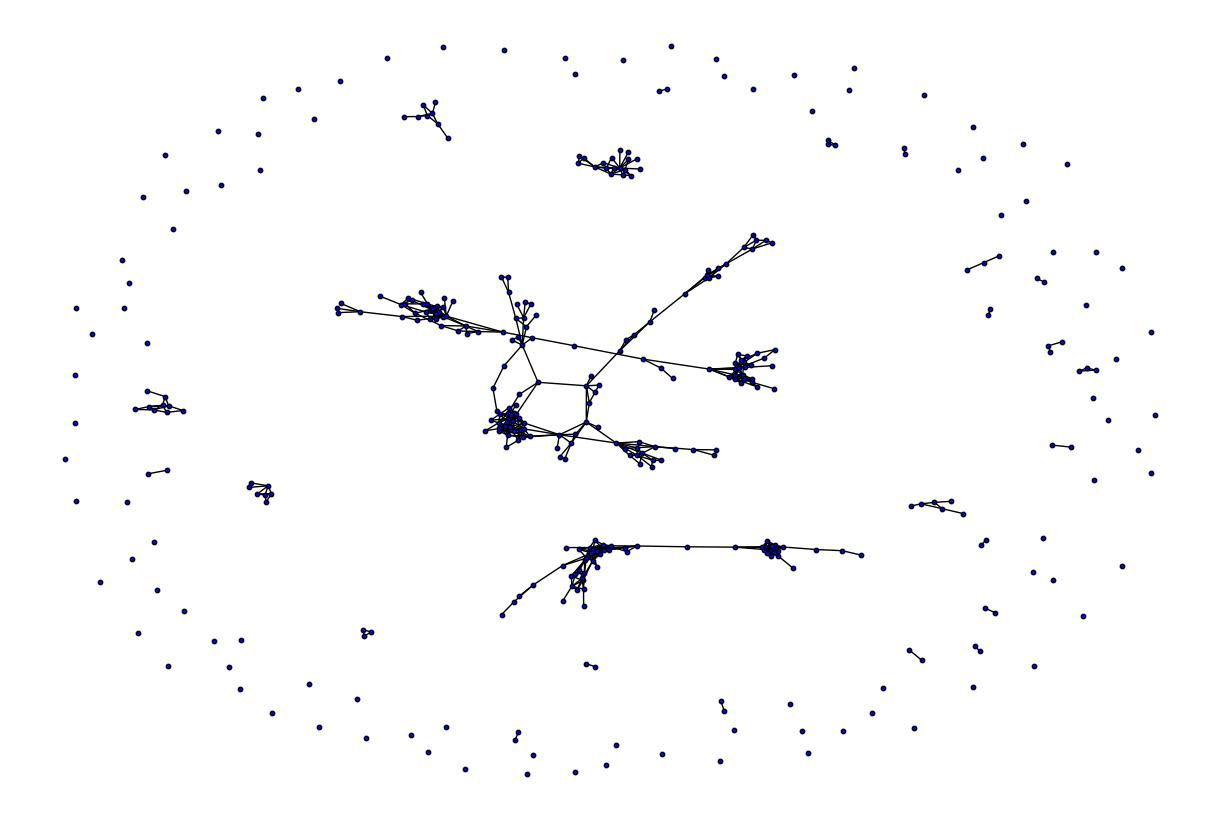

In [11]:
plt.figure(figsize=(12,8))
nx.draw(Amostra_graph, node_color='blue', node_size=10, edge_color='black', edgecolors='black', verticalalignment='center', horizontalalignment='center')
plt.show()

# Calculando cada medida de centralidade
* Grau: indica o grau do nó, quantas arestas se conecta a ele. Nas redes sociais, indica `popularidade/n° de seguidores`
* Intermediação: Quanto o usuário aparece nos caminhos entre outros usuários. Nas redes sociais, se vc segue uma pessoa, talvez vc queira seguir outra pessoa que esta pessoa segue.
* Proximidade: Quão perto o usuário está dos demais nós. Nas redes sociais, usuário que consegue alcançar rapidamente grande parte da rede -> `disseminação de informações`
* Autovetor: Ela não considera apenas quantas pessoas você conhece, Quem são as pessoas que você conhece?, Um nó é importante quando está conectado a outros nós importantes. Nas redes sociais, essa medida pode ser interpretada como `prestígio/influência estrutural`

In [12]:
#Centralidade de Intermediação
intermediacao = nx.betweenness_centrality(Amostra_graph)
#Centralidade de Proximidade
proximidade = nx.closeness_centrality(Amostra_graph)
#Centralidade de grau 
grau = nx.degree_centrality(Amostra_graph)
#Convertendo grau para um int
for chave in grau.keys():
    grau[chave] = grau[chave] * (len(Amostra_graph.nodes()) - 1) # Converte grau para número de conexões
#Centralidade de autovetor 
autovetor = nx.eigenvector_centrality(Amostra_graph)

# Aplicando o Algoritmo de Louvain 
* O Algoritmo de Louvain é um metodo utilizado para a detecção de grupos de nós que apresentam conexões entre si.
* O Algoritmo será utilizado para encontrar as comunidades a qual os usuários pertencem.
* Foi utilizada a biblioteca `python-louvain` para aplicar este algoritmo e calcular as referidas comunidades da rede. 

In [13]:
import community as community_louvain 
particao = community_louvain.best_partition(Amostra_graph)
nx.set_node_attributes(Amostra_graph,particao,'comunidade')
num_comunidades = len(set(particao.values()))

#Teste para ver a quantidade de comunidades 
print("Numero de comunidades: ",num_comunidades)

Numero de comunidades:  132


# Criando um mapa das `comunidades`
* Foi criado um dicionário de comunidades, onde cada chave(comunidade) contém os nós daquela comunidade
* Cria-se um subgrafo de cada uma das comunidades retiradas do dicionário
* Atribui-se uma cor a cada comunidade e depois nó
* O grafo é desenhado com cada cor das comunidades

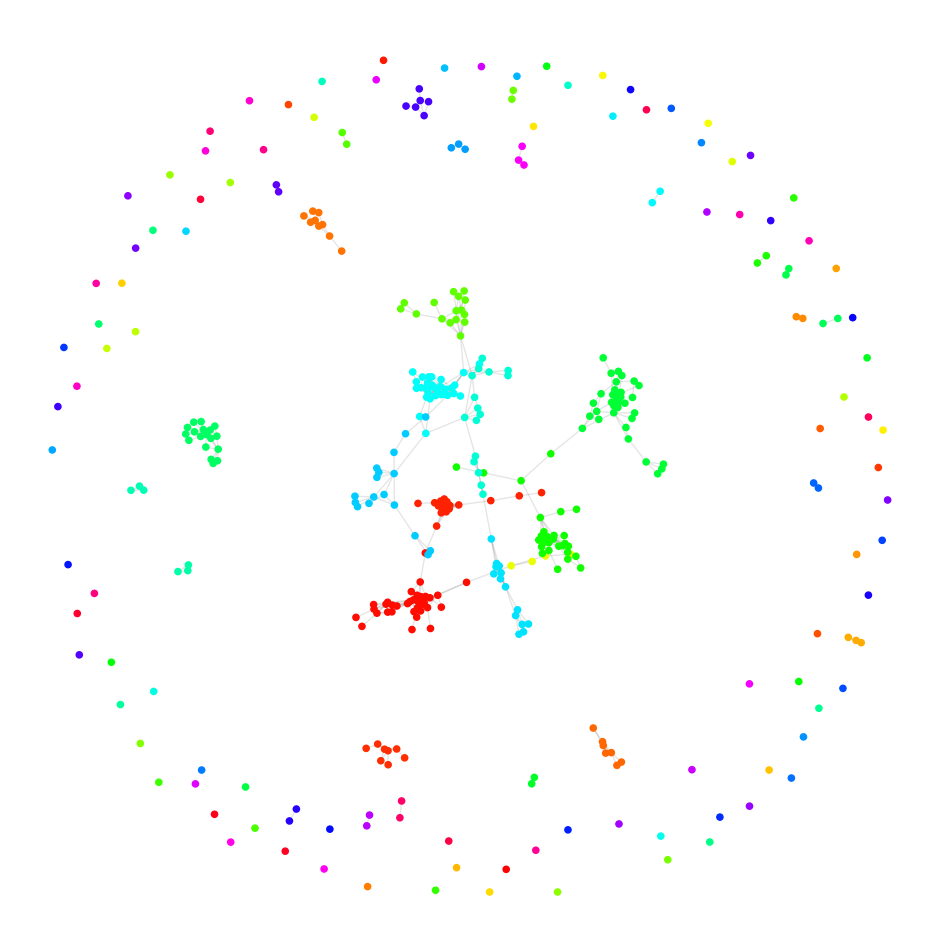

In [14]:
from collections import defaultdict
import matplotlib as mpl

#Agrupa os nós em sua respectiva comunidade
comunidades = defaultdict(list)
#Adicionando os nós na comunidade
for no, comunidade in particao.items():
    comunidades[comunidade].append(no)
#Criando subgrafos para cada comunidade
subgrafo = [Amostra_graph.subgraph(c) for c in comunidades.values()]

# Cria o dicionário id da comunidade -> cor
n = len(comunidades)
# Seleciona um mapa de cores com n cores distintas, hsv é um gradiente de cores
mapa_cor = mpl.colormaps["hsv"].resampled(n)
# Atribui a cor a cada comunidade
cores = {com: mapa_cor(i) for i, com in enumerate(comunidades.keys())}
# Calcula a posição dos nós para o layout do grafo
pos = nx.spring_layout(Amostra_graph, seed=50)
#Atruibui a cor de cada nó de acordo com a comunidade a qual ele pertence
cores_nos = [cores[particao[no]] for no in Amostra_graph.nodes()]

#Desenha o grafo com as cores das comunidades
plt.figure(figsize=(12, 12))
nx.draw_networkx_edges(Amostra_graph, pos, alpha=0.1)
nx.draw_networkx_nodes(Amostra_graph, pos, node_color=cores_nos, node_size=20)
plt.axis( "off" ) 
plt.show()

# Tabela das `métricas de centralidade`
* Cria uma tabela utilizando o DataFrame do pandas
* As colunas seram: nó, métricas de centralidade e comunidade
* Display(HTML) estiliza a tabela
* Show() cria a tabela

In [15]:
import pandas as pd
from itables import show
from IPython.display import display, HTML

# Cria um DataFrame com as medidas de centralidade e a comunidade de cada nó
tabela = pd.DataFrame({
    "no": list(Amostra_graph.nodes()),
    "grau": list(grau.values()),
    "intermediacao": list(intermediacao.values()),
    "proximidade": list(proximidade.values()),
    "autovetor": list(autovetor.values()),
    "comunidade": list(particao.values())
})
# Força texto preto e fundo branco na tabela (tema escuro do editor)
display(HTML("""
<style>
.dt-container, .dt-container *,
table.dataTable th, table.dataTable td,
.dataTables_wrapper, .dataTables_wrapper * {
    color: black !important;
}
table.dataTable, table.dataTable tbody tr {
    background-color: white !important;
}
</style>
"""))
#Monta a tabela
show(tabela.round(5),
    columnDefs=[{"targets": "_all", "orderSequence": ["desc", "asc"]},
    {"targets": [0,5], "orderable": False}],
    order=[[1, "desc"]],
    pageLength=20,
    lengthMenu=[20, 35, 50, 65],    
)

# Destaque de nós de maiores centralidades 

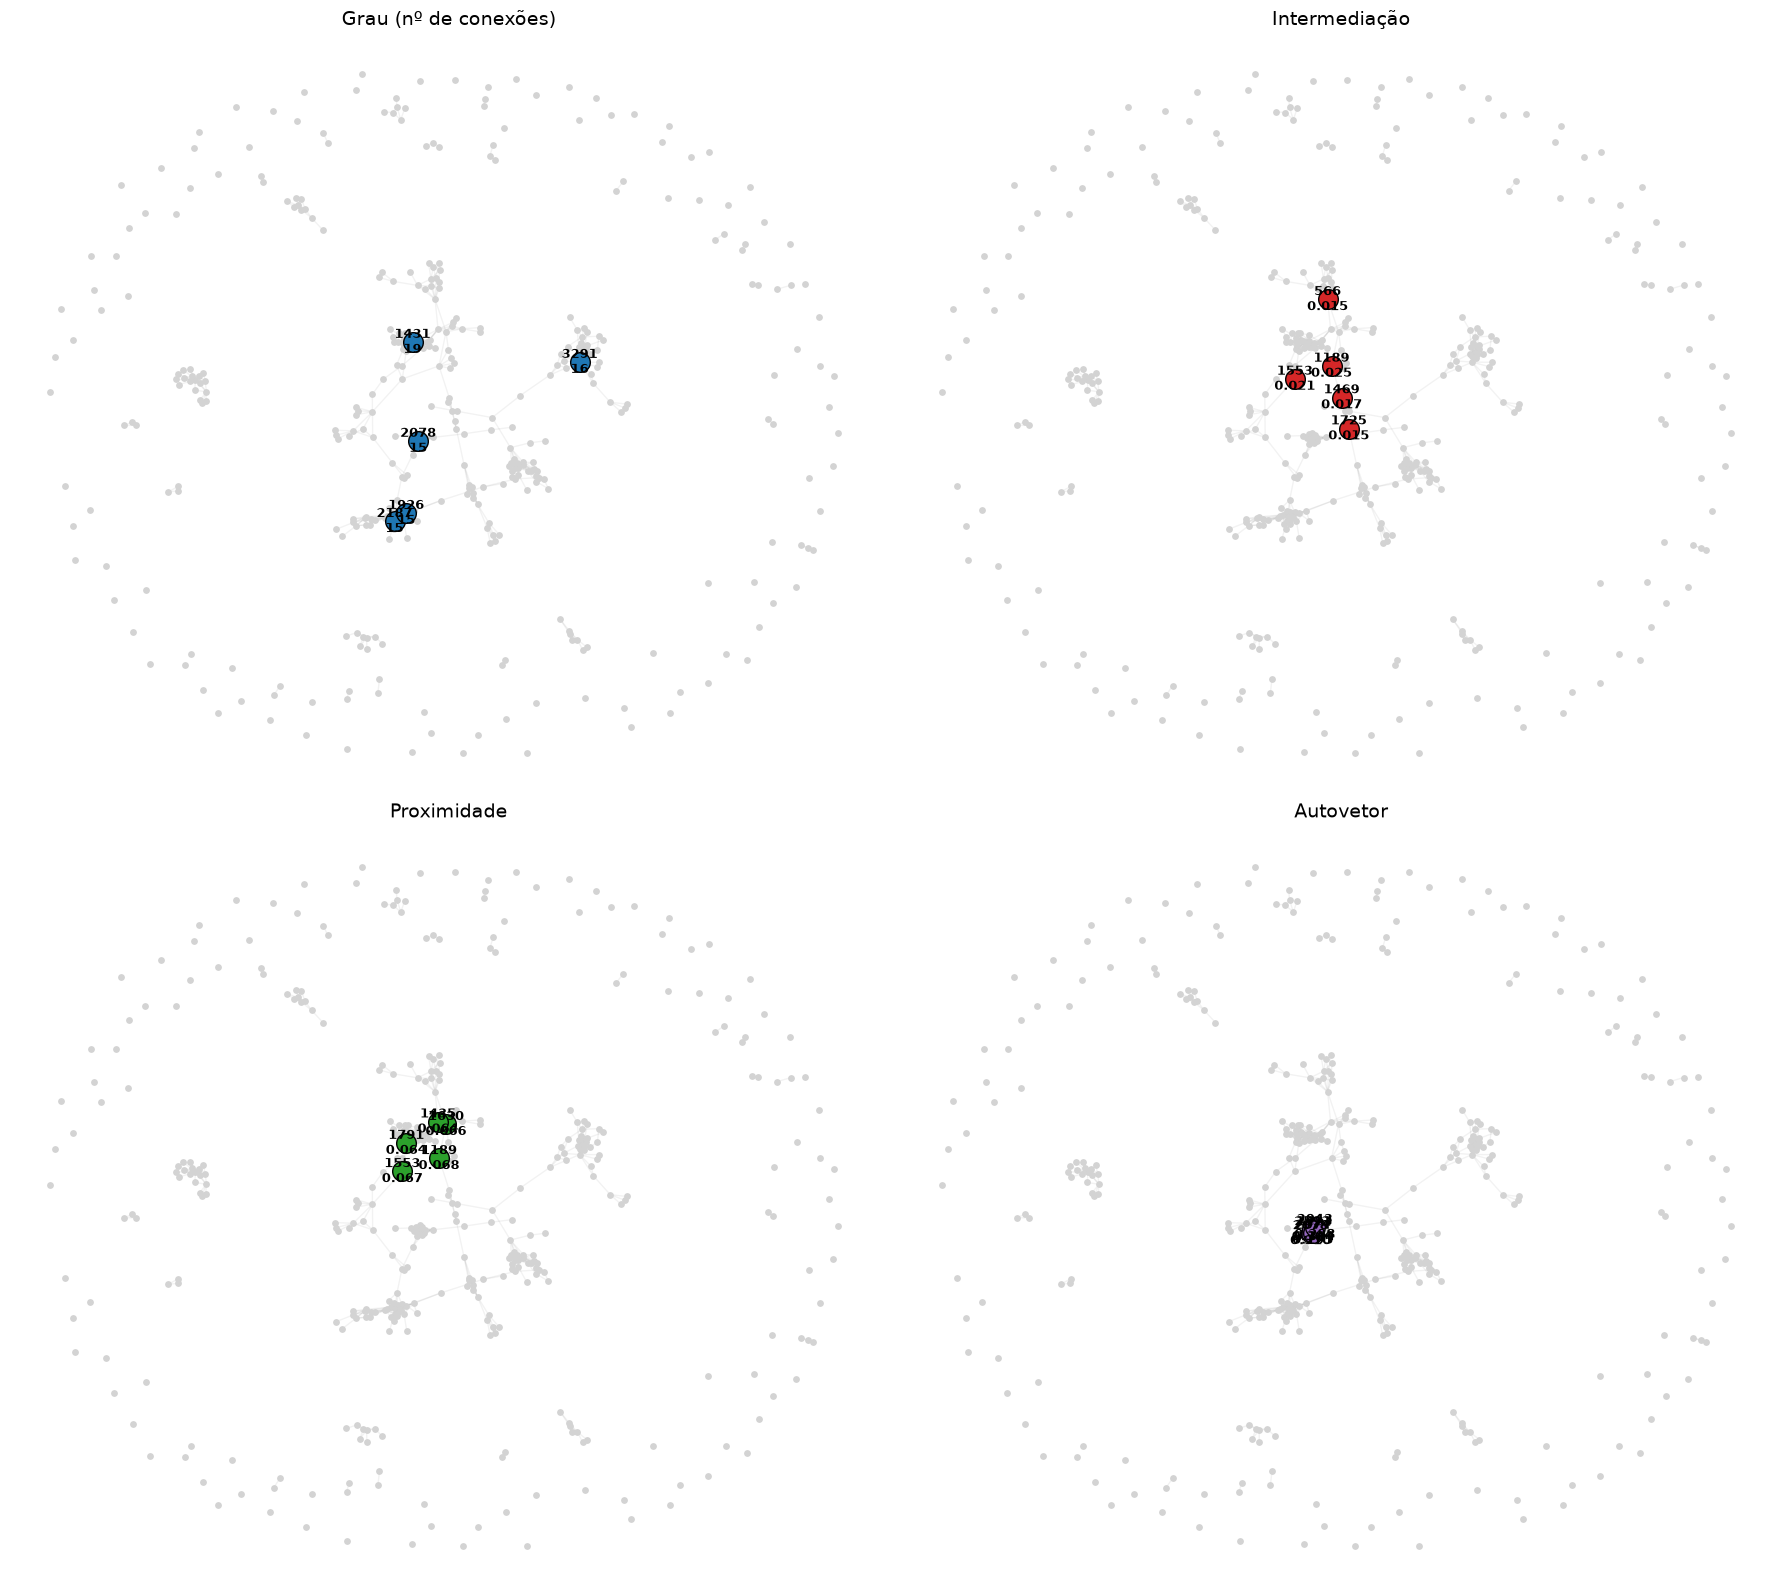

In [16]:
centralidades = {
    "grau": ("#1f77b4", "Grau (nº de conexões)"),
    "intermediacao": ("#d62728", "Intermediação"),
    "proximidade": ("#2ca02c", "Proximidade"),
    "autovetor": ("#9467bd", "Autovetor"),
}

fig, axs = plt.subplots(2, 2, figsize=(18, 16))
pos = nx.spring_layout(Amostra_graph, seed=50)  # mesma posição nos 4 painéis

for ax, (coluna, (cor, titulo)) in zip(axs.flat, centralidades.items()):
    top5 = tabela.nlargest(5, coluna)
    nos_top = list(top5["no"])
    valores = dict(zip(top5["no"], top5[coluna]))

    nx.draw_networkx_edges(Amostra_graph, pos, ax=ax, alpha=0.05)
    nx.draw_networkx_nodes(Amostra_graph, pos, ax=ax,
                           node_color="lightgray", node_size=15)
    nx.draw_networkx_nodes(Amostra_graph, pos, nodelist=nos_top, ax=ax,
                           node_color=cor, node_size=200, edgecolors="black")

    rotulos = {no: (f"{no}\n{valores[no]:.0f}" if coluna == "grau"
                    else f"{no}\n{valores[no]:.3f}") for no in nos_top}
    nx.draw_networkx_labels(Amostra_graph, pos, labels=rotulos, ax=ax,
                            font_size=9, font_weight="bold")

    ax.set_title(titulo, fontsize=14)
    ax.axis("off")

plt.tight_layout()
plt.show()